In [ ]:
import json, pickle
import random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import csv
import pandas as pd
import time
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt

# Load data
with open("../stimuli/coco_caption_concereteness_with_lemmatization.json") as f:
    data = json.load(f)

for i, img in enumerate(data):
    max_score, min_score = 0, 100
    max_id, min_id = 0, 0
    for c, cap in enumerate(img['caption_concreteness']):
        mean_score = mean(cap['concreteness'])
        data[i]['caption_concreteness'][c]['concrete_score'] = mean_score
        data[i]['caption_concreteness'][c]['abstract_score'] = mean_score
        if mean_score > max_score:
            max_score = mean_score
            max_id = cap['id']
        if mean_score < min_score:
            min_score = mean_score
            min_id = cap['id']
    data[i]['concrete_abstact_diff'] = {
        'value' : max_score - min_score,
        'ids': [max_id, min_id],
}

all_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var", "abstract_score", "concrete_score"]
test_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var"]

# Filter entries with both concrete and abstract ids
filtered_data = [item for item in data if len(set(item['concrete_abstact_diff']['ids'])) > 1]
filtered_data = sorted(filtered_data, key=lambda x: x['concrete_abstact_diff']['value'], reverse=True)

def extract_attr_lists(data_subset):
    ids = []
    abs_captions = []
    con_captions = []
    value_diffs = []
    abs_vals = {attr: [] for attr in all_attributes}
    con_vals = {attr: [] for attr in all_attributes}

    for entry in data_subset:
        ids.append(entry['image'])
        value_diffs.append(entry['concrete_abstact_diff']['value'])
        con_id, abs_id = entry['concrete_abstact_diff']['ids']
        con_cap = next(c for c in entry['caption_concreteness'] if c['id'] == con_id)
        abs_cap = next(c for c in entry['caption_concreteness'] if c['id'] == abs_id)

        abs_captions.append(abs_cap)
        con_captions.append(con_cap)

        for attr in ["concrete_score", "abstract_score"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        if 'char_number' in all_attributes:
            abs_vals['char_number'].append(len(abs_cap['caption']))
            con_vals['char_number'].append(len(con_cap['caption']))

        if 'word_number' in all_attributes:
            abs_vals['word_number'].append(len(abs_cap['caption'].split(' ')))
            con_vals['word_number'].append(len(con_cap['caption'].split(' ')))

        for attr in ["matching_score", "emap_var"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        for attr in ["word_importances", "word_frequency"]:
            if attr in all_attributes:
                abs_vals[attr].append(mean(abs_cap[attr]))
                con_vals[attr].append(mean(con_cap[attr]))

    return ids, value_diffs, abs_captions, con_captions, abs_vals, con_vals

ids_all, value_diffs_all, _, _, abs_vals_all, con_vals_all = extract_attr_lists(filtered_data)

## Distributions

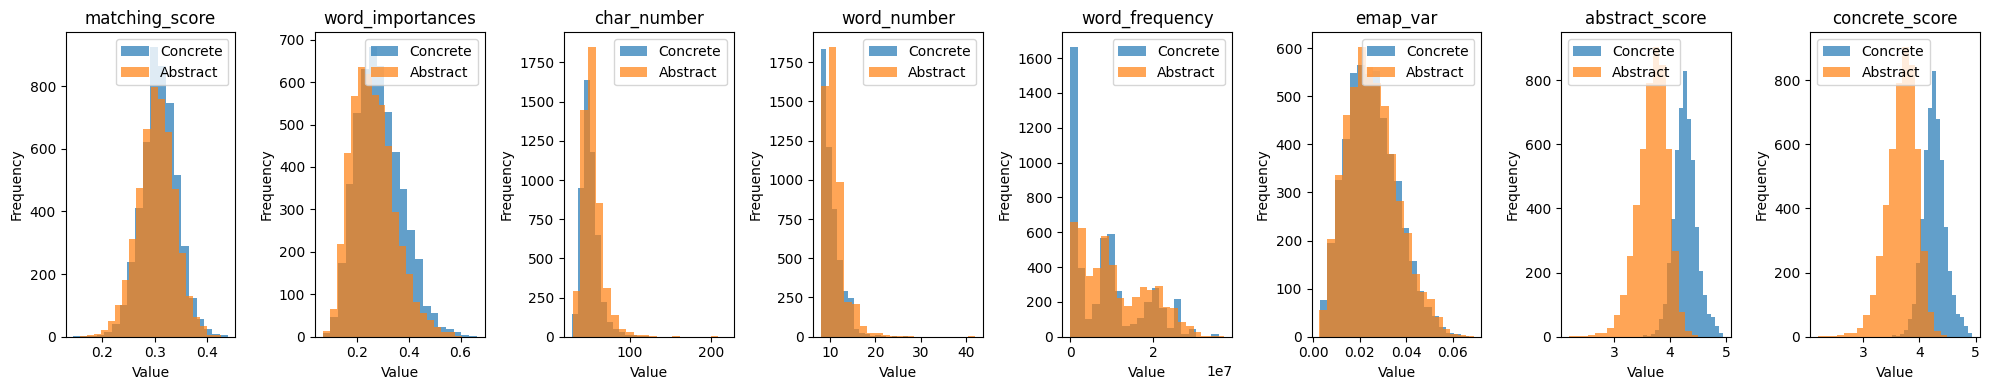

In [2]:
# Plot distributions for each attribute (all data)
fig, axs = plt.subplots(1, len(all_attributes), figsize=(20, 4))
for i, attr in enumerate(all_attributes):
    axs[i].hist(con_vals_all[attr], bins=20, alpha=0.7, label='Concrete')
    axs[i].hist(abs_vals_all[attr], bins=20, alpha=0.7, label='Abstract')
    axs[i].set_title(attr)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')
    axs[i].legend()

plt.tight_layout()
plt.show()

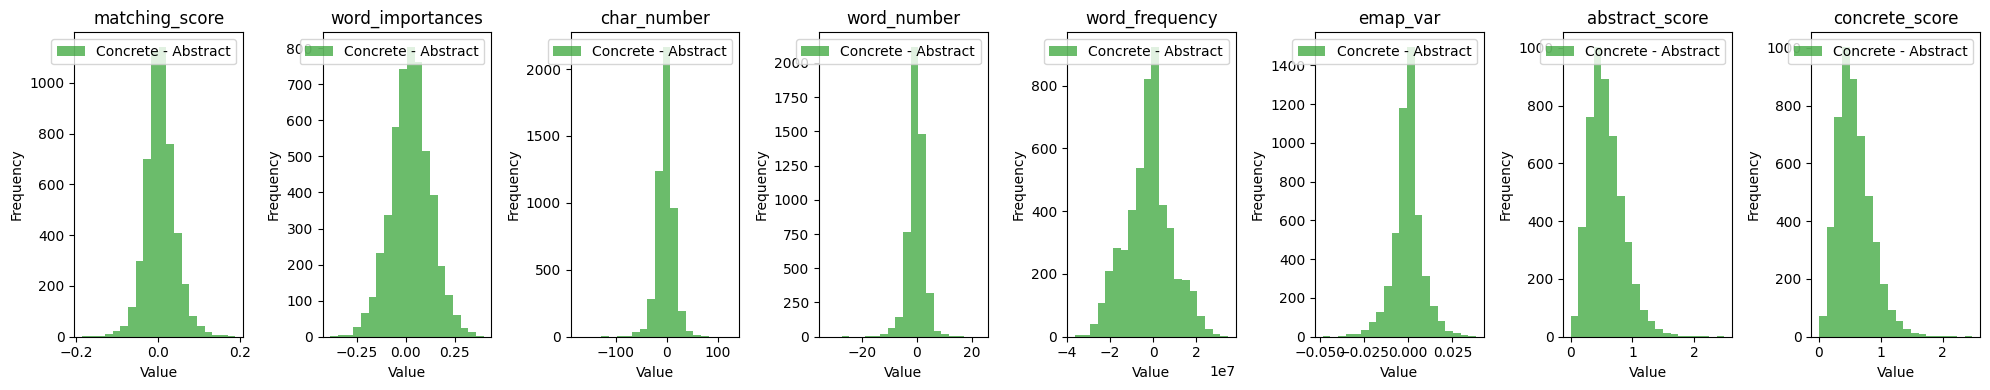

In [3]:
# Plot distributions for each attribute
fig, axs = plt.subplots(1, len(all_attributes), figsize=(20, 4))
for i, attr in enumerate(all_attributes):
    axs[i].hist(np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr])), bins=20, alpha=0.7, color="tab:green", label='Concrete - Abstract')
    axs[i].set_title(attr)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')
    axs[i].legend()

plt.tight_layout()
plt.show()

Concrete score mean of concrete captions:  4.269285930678188
Abstract score mean of concrete captions:  4.074893421076236
Abstract score mean of abstract captions:  3.6912611683414824
Concrete score mean of abstract captions:  3.9572657474127078
Mean of Concrete - Abstract 0.5780247623367049


/tmp/ipykernel_3534440/964651755.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend()


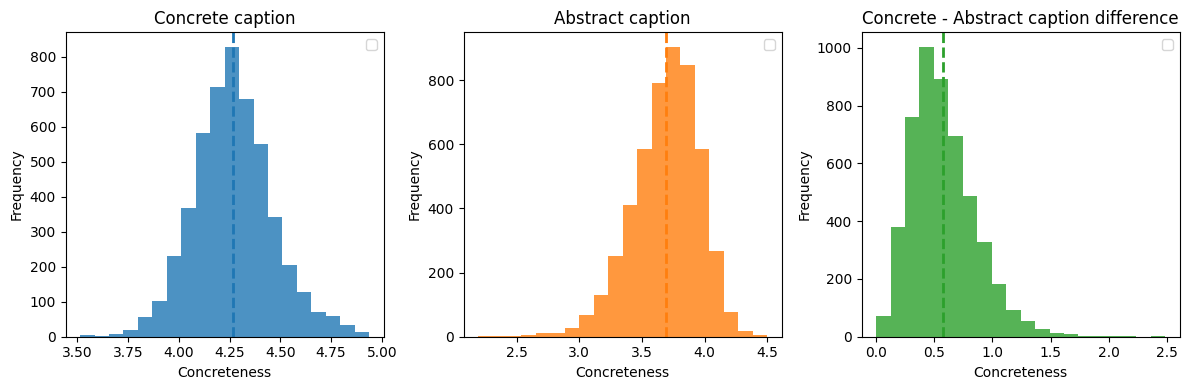

In [4]:
# Get threshold for concrete and abstract captions
concrete_con_threshold = np.mean(con_vals_all["concrete_score"])
concrete_abs_threshold = np.mean(con_vals_all["abstract_score"]) - np.std(con_vals_all["abstract_score"])
print("Concrete score mean of concrete captions: ", concrete_con_threshold)
print("Abstract score mean of concrete captions: ", concrete_abs_threshold)

abstract_abs_threshold = np.mean(abs_vals_all["abstract_score"])
abstract_con_threshold = np.mean(abs_vals_all["concrete_score"]) + np.std(abs_vals_all["concrete_score"])
print("Abstract score mean of abstract captions: ", abstract_abs_threshold)
print("Concrete score mean of abstract captions: ", abstract_con_threshold)

diff_threshold = np.mean(np.asarray(con_vals_all["concrete_score"]) - np.asarray((abs_vals_all["abstract_score"])))
print("Mean of Concrete - Abstract", diff_threshold)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].set_title("Concrete caption")

axs[0].hist(con_vals_all["concrete_score"], bins=20, color="tab:blue", alpha=0.8)
axs[0].axvline(x=concrete_con_threshold, color="tab:blue", linestyle='--', linewidth=2)

axs[1].set_title("Abstract caption")
axs[1].hist(abs_vals_all["abstract_score"], bins=20, color="tab:orange", alpha=0.8)
axs[1].axvline(x=abstract_abs_threshold, color="tab:orange", linestyle='--', linewidth=2)

axs[2].set_title("Concrete - Abstract caption difference")
axs[2].hist(np.asarray(con_vals_all["concrete_score"]) - np.asarray((abs_vals_all["abstract_score"])), bins=20, alpha=0.8, color="tab:green")
axs[2].axvline(x=diff_threshold, color="tab:green", linestyle='--', linewidth=2)

for i in range(3):
    axs[i].set_xlabel('Concreteness')
    axs[i].set_ylabel('Frequency')
    axs[i].legend()

plt.tight_layout()
plt.show()

plt
plt.show()

In [5]:
for i, attr in enumerate(all_attributes):
    # Paired t-test on the selected samples
    print(f"Attribute: {attr}")
    t_stat_sel, p_value_sel = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
    print(f"paired t-statistic (all): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")
    t_stat_sel, p_value_sel = ttest_ind(con_vals_all[attr], abs_vals_all[attr])
    print(f"unpaired t-statistic (all): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")

Attribute: matching_score
paired t-statistic (all): 11.8855, p-value: 0.0000
unpaired t-statistic (all): 8.9436, p-value: 0.0000
Attribute: word_importances
paired t-statistic (all): 17.4910, p-value: 0.0000
unpaired t-statistic (all): 14.7873, p-value: 0.0000
Attribute: char_number
paired t-statistic (all): -13.0340, p-value: 0.0000
unpaired t-statistic (all): -12.7794, p-value: 0.0000
Attribute: word_number
paired t-statistic (all): -9.4016, p-value: 0.0000
unpaired t-statistic (all): -9.1905, p-value: 0.0000
Attribute: word_frequency
paired t-statistic (all): -14.3080, p-value: 0.0000
unpaired t-statistic (all): -13.3990, p-value: 0.0000
Attribute: emap_var
paired t-statistic (all): -2.2154, p-value: 0.0268
unpaired t-statistic (all): -1.2112, p-value: 0.2258
Attribute: abstract_score
paired t-statistic (all): 148.7696, p-value: 0.0000
unpaired t-statistic (all): 124.0202, p-value: 0.0000
Attribute: concrete_score
paired t-statistic (all): 148.7696, p-value: 0.0000
unpaired t-statis

In [6]:
exlucded_ids = ['val2014/COCO_val2014_000000261787.jpg', # inappropriate
                'val2014/COCO_val2014_000000058462.jpg', # mispelled
                'val2014/COCO_val2014_000000053952.jpg', # incorrect
                'val2014/COCO_val2014_000000125069.jpg', # not correct
                'val2014/COCO_val2014_000000561517.jpg', # not correct
                'val2014/COCO_val2014_000000102439.jpg', # mispelled
                'val2014/COCO_val2014_000000425227.jpg', # confusing
                'val2014/COCO_val2014_000000557172.jpg',

                'val2014/COCO_val2014_000000125076.jpg', # manual check
                'val2014/COCO_val2014_000000535934.jpg',
                'val2014/COCO_val2014_000000526021.jpg',
                'val2014/COCO_val2014_000000349888.jpg',
                'val2014/COCO_val2014_000000102159.jpg',
                'val2014/COCO_val2014_000000026622.jpg',
                'val2014/COCO_val2014_000000402662.jpg',
                'val2014/COCO_val2014_000000446574.jpg',
                'val2014/COCO_val2014_000000155355.jpg',
                'val2014/COCO_val2014_000000392928.jpg',
                'val2014/COCO_val2014_000000303210.jpg',
                'val2014/COCO_val2014_000000226579.jpg',
                'val2014/COCO_val2014_000000172079.jpg',
                'val2014/COCO_val2014_000000498596.jpg',
                'val2014/COCO_val2014_000000505169.jpg',
                'val2014/COCO_val2014_000000455315.jpg',
                'val2014/COCO_val2014_000000359314.jpg',
                'val2014/COCO_val2014_000000289900.jpg',
                'val2014/COCO_val2014_000000335670.jpg',
                'val2014/COCO_val2014_000000054092.jpg',
                'val2014/COCO_val2014_000000226069.jpg',
                'val2014/COCO_val2014_000000268247.jpg',
                'val2014/COCO_val2014_000000476841.jpg',
                'val2014/COCO_val2014_000000044022.jpg',
                'val2014/COCO_val2014_000000093476.jpg',
                'val2014/COCO_val2014_000000001464.jpg',
                'val2014/COCO_val2014_000000077951.jpg',
                'val2014/COCO_val2014_000000265719.jpg',
                'val2014/COCO_val2014_000000081248.jpg',
                'val2014/COCO_val2014_000000071826.jpg',
                'val2014/COCO_val2014_000000195862.jpg',
                'val2014/COCO_val2014_000000361430.jpg',
                'val2014/COCO_val2014_000000149780.jpg',
                'val2014/COCO_val2014_000000576774.jpg',
                'val2014/COCO_val2014_000000113251.jpg',
                'val2014/COCO_val2014_000000279279.jpg',
                'val2014/COCO_val2014_000000533137.jpg',
                'val2014/COCO_val2014_000000204757.jpg',
                'val2014/COCO_val2014_000000207108.jpg',
                'val2014/COCO_val2014_000000553081.jpg',
                'val2014/COCO_val2014_000000034167.jpg',
                'val2014/COCO_val2014_000000052982.jpg',
                'val2014/COCO_val2014_000000193121.jpg',
                'val2014/COCO_val2014_000000235241.jpg',
                'val2014/COCO_val2014_000000579438.jpg',
                'val2014/COCO_val2014_000000158222.jpg',
                'val2014/COCO_val2014_000000412639.jpg',
                'val2014/COCO_val2014_000000435387.jpg',
                'val2014/COCO_val2014_000000231855.jpg',
                'val2014/COCO_val2014_000000089670.jpg',
                'val2014/COCO_val2014_000000434990.jpg',
                'val2014/COCO_val2014_000000282591.jpg',
                'val2014/COCO_val2014_000000538775.jpg',
                'val2014/COCO_val2014_000000218060.jpg',
                'val2014/COCO_val2014_000000570594.jpg',
                'val2014/COCO_val2014_000000413709.jpg',
                'val2014/COCO_val2014_000000094317.jpg',
                'val2014/COCO_val2014_000000025138.jpg',
                'val2014/COCO_val2014_000000036414.jpg',
                'val2014/COCO_val2014_000000489346.jpg',
                'val2014/COCO_val2014_000000051984.jpg',
                'val2014/COCO_val2014_000000507361.jpg',
                'val2014/COCO_val2014_000000233834.jpg',
                'val2014/COCO_val2014_000000202609.jpg',
                'val2014/COCO_val2014_000000413522.jpg',
                'val2014/COCO_val2014_000000499571.jpg',
                'val2014/COCO_val2014_000000436130.jpg',
                'val2014/COCO_val2014_000000274931.jpg',
                'val2014/COCO_val2014_000000578813.jpg',
                'val2014/COCO_val2014_000000239235.jpg',
                'val2014/COCO_val2014_000000480652.jpg',
                'val2014/COCO_val2014_000000107257.jpg',
                'val2014/COCO_val2014_000000199688.jpg',
                'val2014/COCO_val2014_000000092804.jpg',
                'val2014/COCO_val2014_000000397427.jpg',
                'val2014/COCO_val2014_000000396556.jpg',
                'val2014/COCO_val2014_000000064574.jpg',
                'val2014/COCO_val2014_000000464633.jpg',
                'val2014/COCO_val2014_000000382758.jpg',
                'val2014/COCO_val2014_000000006810.jpg',
                'val2014/COCO_val2014_000000442210.jpg',
                'val2014/COCO_val2014_000000000474.jpg',
                'val2014/COCO_val2014_000000079408.jpg',
                'val2014/COCO_val2014_000000005728.jpg',
                'val2014/COCO_val2014_000000446285.jpg',
                'val2014/COCO_val2014_000000040275.jpg',
                'val2014/COCO_val2014_000000177258.jpg',
                'val2014/COCO_val2014_000000159223.jpg',
                'val2014/COCO_val2014_000000313718.jpg',
                'val2014/COCO_val2014_000000104691.jpg',
                'val2014/COCO_val2014_000000384794.jpg',
                'val2014/COCO_val2014_000000550432.jpg',
                'val2014/COCO_val2014_000000566436.jpg',
                ]

preliminary filtering

In [7]:
from scipy.stats import ttest_rel
import random

preserved_indices = []

# # Step 1: Control importance
# attr = "word_importances"
# print(f"Attribute: {attr}")
# t_stat, p_value = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
# print(f"(All) t-statistic: {t_stat}, p-value: {p_value}")
# all_diff = np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr]))
# selected_indices_temp = [
#     idx for idx, diff in enumerate(all_diff)
#     if -0.02 <= diff <= 0.02 # hand-picked
# ]
# print(len(selected_indices_temp))
# preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

# attr = "matching_score"
# print(f"Attribute: {attr}")
# t_stat, p_value = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
# print(f"(All) t-statistic: {t_stat}, p-value: {p_value}")
# all_diff = np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr]))
# selected_indices_temp = [
#     idx for idx, diff in enumerate(all_diff)
#     if -0.04 <= diff <= 0.04 # hand-picked
# ]
# print(len(selected_indices_temp))
# preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

attr = "char_number"
print(f"Attribute: {attr}")
t_stat, p_value = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
print(f"(All) t-statistic: {t_stat}, p-value: {p_value}")
all_diff = np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr]))
selected_indices_temp = [
    idx for idx, diff in enumerate(all_diff)
    if con_vals_all[attr][idx] <= 100 and abs_vals_all[attr][idx] <= 100 # hand-picked
]
print(len(selected_indices_temp))
preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

# attr = "word_number"
# print(f"Attribute: {attr}")
# t_stat, p_value = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
# print(f"(All) t-statistic: {t_stat}, p-value: {p_value}")
# all_diff = np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr]))
# selected_indices_temp = [
#     idx for idx, diff in enumerate(all_diff)
#     if -15 <= diff <= 15
# ]
# print(len(selected_indices_temp))
# preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

# attr = "word_frequency"
# print(f"Attribute: {attr}")
# t_stat, p_value = ttest_rel(con_vals_all[attr], abs_vals_all[attr])
# print(f"(All) t-statistic: {t_stat}, p-value: {p_value}")
# all_diff = np.asarray(con_vals_all[attr]) - np.asarray((abs_vals_all[attr]))
# selected_indices_temp = [
#     idx for idx, diff in enumerate(all_diff)
#     if -np.mean(np.abs(all_diff)) <= diff <= np.mean(np.abs(all_diff))
# ]
# print(len(selected_indices_temp))
# preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

# Step 2: Control concreteness
# concreteness score
print(f"Attribute: concrete_score")
selected_indices_temp = [
    idx for idx in range(len(con_vals_all["concrete_score"]))
    if con_vals_all["concrete_score"][idx] >= concrete_con_threshold and\
        # con_vals_all["abstract_score"][idx] >= concrete_abs_threshold and\
        abs_vals_all["abstract_score"][idx] <= abstract_abs_threshold and\
        # abs_vals_all["concrete_score"][idx] <= abstract_con_threshold and\
        (con_vals_all["concrete_score"][idx] - abs_vals_all["abstract_score"][idx] >= diff_threshold) # hand-picked
]
print(len(selected_indices_temp))
preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

# # Step 3: Manual inspection
# print(f"Manual inspection")
# selected_indices_temp = [
#     idx for idx, id in enumerate(ids_all)
#     if id.split('/')[-1] in included_ids # hand-picked
# ]
# print(len(selected_indices_temp))
# preserved_indices = list(set(preserved_indices) & set(selected_indices_temp)) if preserved_indices else selected_indices_temp

preserved_indices = list(set(preserved_indices) - set([filtered_data.index(item) for item in filtered_data if item['image'] in exlucded_ids]))

print(f"Final set: {len(preserved_indices)}")

preserved_indices.sort()

Attribute: char_number
(All) t-statistic: -13.033986105183725, p-value: 3.271818849618711e-38
4937
Attribute: concrete_score
842
Final set: 733


### Random Sampling util all tests pass

In [ ]:
def ttests_pass(abs_vals, con_vals, attributes, alpha=0.1):
    failed_attributes = []
    pass_all = True
    for attr in attributes:
        _, p = ttest_rel(abs_vals[attr], con_vals[attr])
        if p <= alpha:
            pass_all = False
            failed_attributes.append(attr)
    return pass_all, failed_attributes

# randomly sample 80 images that maximize concreteness difference and pass all t tests
num_trials = 1000000
selected_indices = None
selected_indices_all = []
total_diff_all = []
best_total_diff = -np.inf
passed_count = 0

failed_attrs_all = []

for _ in tqdm(range(num_trials)):
    preserved_indices_other = list(set(preserved_indices))
    sample = random.sample(preserved_indices_other, 80)

    temp_entries = [filtered_data[idx] for idx in sample]
    ids_temp, value_diffs_temp, _, _, abs_vals_temp, con_vals_temp = extract_attr_lists(temp_entries)

    passed, failed_attrs = ttests_pass(abs_vals_temp, con_vals_temp, test_attributes)

    if passed:
        passed_count += 1
        total_diff = sum(value_diffs_temp)
        selected_indices_all.append(sample)
        total_diff_all.append(total_diff)
        if total_diff > best_total_diff:
            best_total_diff = total_diff
            selected_indices = sample

    else:
        failed_attrs_all += failed_attrs

print(f"Passed t-tests in {passed_count} out of {num_trials} trials.")

  0%|          | 0/1000000 [00:00<?, ?it/s]

100%|██████████| 1000000/1000000 [2:03:47<00:00, 134.64it/s] 

Passed t-tests in 36 out of 1000000 trials.


In [23]:
import pickle
ids_all = []

for indices in selected_indices_all:
    ids = [filtered_data[i]['image'] for i in indices]
    ids_all.append(ids)

with open("ids_all_80_250723.pkl", "wb") as f:
    pickle.dump(ids_all, f)

### Loading sampled ids

In [14]:
with open("ids_all_80_250708.pkl", "rb") as f:
    ids_all = pickle.load(f)

selected_indices_all = []
for ids in ids_all:
    selected_indices_all.append([filtered_data.index(item) for item in filtered_data if item['image'] in ids])

In [21]:
import pickle

with open("selected_indices.pkl", "wb") as f:
    pickle.dump(selected_indices, f)
with open("selected_indices_all.pkl", "wb") as f:
    pickle.dump(selected_indices_all, f)
with open("total_diff_all.pkl", "wb") as f:
    pickle.dump(total_diff_all, f)

In [22]:
selected_indices = []
saved = pd.read_csv("/home/jinhanz/cs/concreteness/processing/stimuli_average/20250619_115432/captions_and_attributes.csv")
saved_ids = saved['image_id'].tolist()
for e, entry in enumerate(filtered_data):
    if entry['image'] in saved_ids:
        selected_indices.append(e)

Attribute: matching_score
paired t-statistic (selected): 1.0684, p-value: 0.2886
unpaired t-statistic (selected): 0.9223, p-value: 0.3578
Attribute: word_importances
paired t-statistic (selected): 1.5545, p-value: 0.1241
unpaired t-statistic (selected): 1.3982, p-value: 0.1640
Attribute: char_number
paired t-statistic (selected): -1.3166, p-value: 0.1918
unpaired t-statistic (selected): -1.3312, p-value: 0.1850
Attribute: word_number
paired t-statistic (selected): -0.8776, p-value: 0.3828
unpaired t-statistic (selected): -0.9092, p-value: 0.3646
Attribute: word_frequency
paired t-statistic (selected): -1.5262, p-value: 0.1310
unpaired t-statistic (selected): -1.4939, p-value: 0.1372
Attribute: emap_var
paired t-statistic (selected): 0.3680, p-value: 0.7138
unpaired t-statistic (selected): 0.2035, p-value: 0.8390
Attribute: abstract_score
paired t-statistic (selected): 35.5774, p-value: 0.0000
unpaired t-statistic (selected): 35.0603, p-value: 0.0000
Attribute: concrete_score
paired t-s

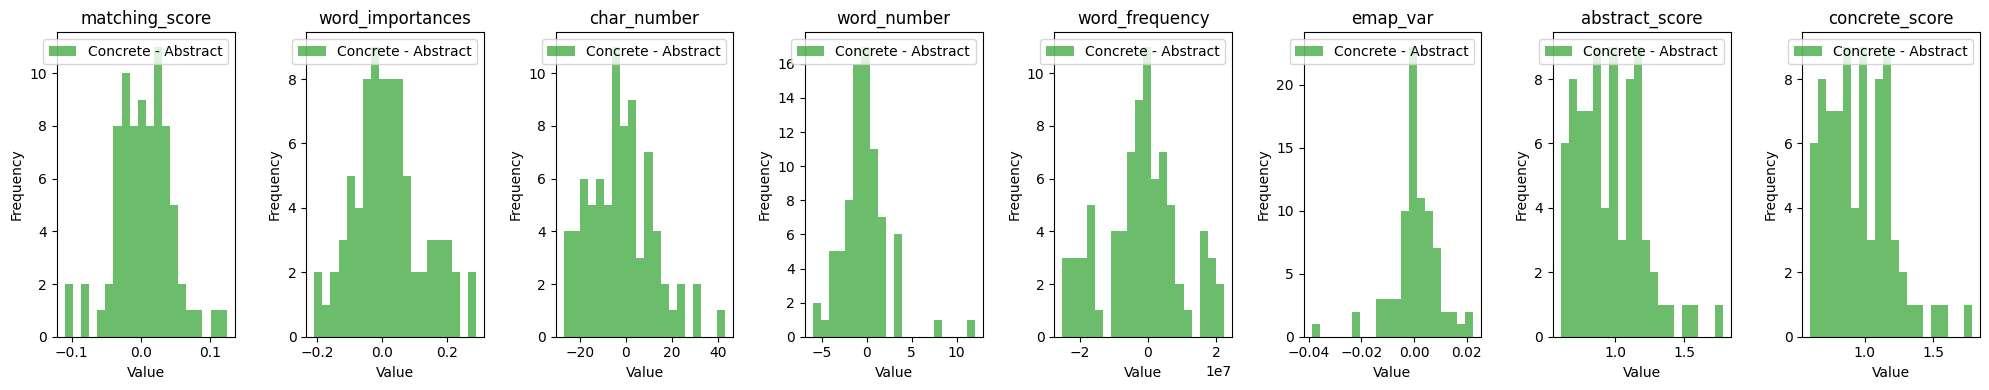

Attribute: concrete vs abstract
paired t-statistic (selected): 35.5774, p-value: 0.0000
unpaired t-statistic (selected): 35.0603, p-value: 0.0000


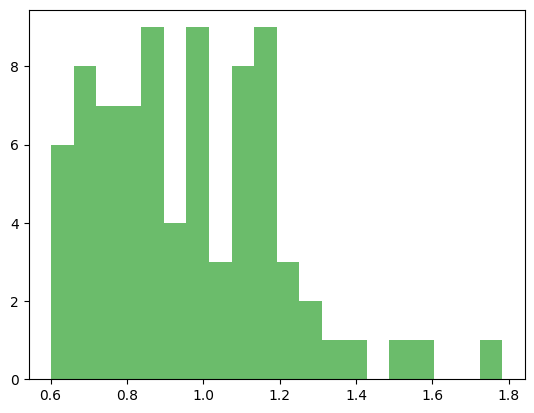

In [26]:
selected_indices.sort()
selected_entries = [filtered_data[idx] for idx in selected_indices]

ids_selected, value_diffs_selected, abs_captions_selected, con_captions_selected, abs_vals_selected, con_vals_selected = extract_attr_lists(selected_entries)

# Plot distributions for each attribute
fig, axs = plt.subplots(1, len(all_attributes), figsize=(20, 4))
for i, attr in enumerate(all_attributes):
    # Paired t-test on the selected samples
    print(f"Attribute: {attr}")
    t_stat_sel, p_value_sel = ttest_rel(con_vals_selected[attr], abs_vals_selected[attr])
    print(f"paired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")
    t_stat_sel, p_value_sel = ttest_ind(con_vals_selected[attr], abs_vals_selected[attr])
    print(f"unpaired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")

    axs[i].hist(np.asarray(con_vals_selected[attr]) - np.asarray((abs_vals_selected[attr])), bins=20, alpha=0.7, color="tab:green", label='Concrete - Abstract')
    axs[i].set_title(attr)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')
    axs[i].legend()

plt.tight_layout()
plt.show()

print(f"Attribute: concrete vs abstract")
t_stat_sel, p_value_sel = ttest_rel(con_vals_selected["concrete_score"], abs_vals_selected["abstract_score"])
print(f"paired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")
t_stat_sel, p_value_sel = ttest_ind(con_vals_selected["concrete_score"], abs_vals_selected["abstract_score"])
print(f"unpaired t-statistic (selected): {t_stat_sel:.4f}, p-value: {p_value_sel:.4f}")

plt.hist(np.asarray(con_vals_selected["concrete_score"]) - np.asarray((abs_vals_selected["abstract_score"])), bins=20, alpha=0.7, color="tab:green", label='Concrete - Abstract')
plt.show()

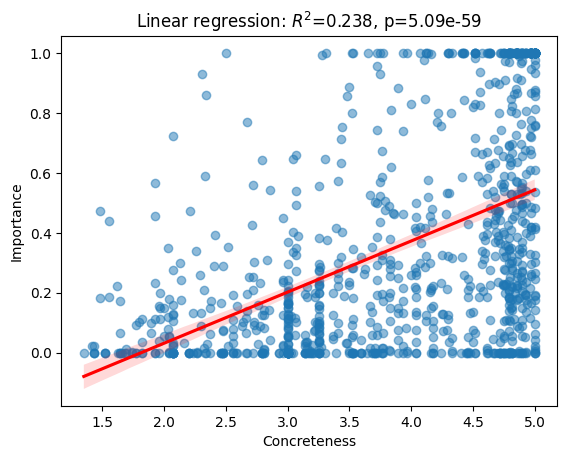

Slope: 0.1705, Intercept: -0.3097, R^2: 0.2378, p-value: 5.0892e-59


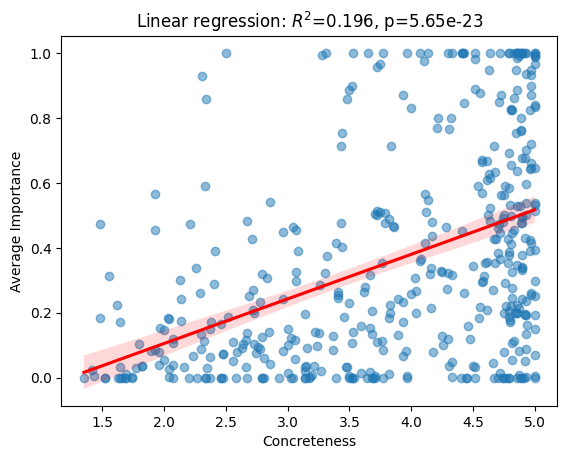

Slope: 0.1372, Intercept: -0.1694, R^2: 0.1956, p-value: 5.6473e-23


In [15]:
import os
from PIL import Image, ImageDraw, ImageFont
from datetime import datetime
import csv
import seaborn as sns
from scipy.stats import linregress
from collections import defaultdict

from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()

# quantative analysis: actual importance vs concreteness
all_importances_selected = []
all_concreteness_selected = []
for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected, abs_captions_selected, con_captions_selected)):
    for cap in [abs_cap, con_cap]:
        for word, importance in zip(cap['caption'].strip('.,!?\'" ').split(), cap['word_importances']):
            word_clean = word.strip('.,!?\'"')
            vocab = word_clean.lower()
            vocab = vocab if vocab in cap['words'] else wnl.lemmatize(vocab)

            if vocab not in cap['words']:
                continue

            idx = cap['words'].index(vocab)
            concreteness = cap['concreteness'][idx]
            all_importances_selected.append(importance)
            all_concreteness_selected.append(concreteness)

slope, intercept, r_value, p_value, std_err = linregress(all_concreteness_selected, all_importances_selected)
sns.regplot(x=all_concreteness_selected, y=all_importances_selected, line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})
plt.xlabel("Concreteness")
plt.ylabel("Importance")
plt.title(f"Linear regression: $R^2$={r_value**2:.3f}, p={p_value:.2e}")
plt.show()
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R^2: {r_value**2:.4f}, p-value: {p_value:.4e}")

# quantative analysis: average importance vs concreteness
all_importances_selected = []
all_concreteness_selected = []

all_importances_selected_dict = defaultdict(list)
all_concreteness_selected_dict = defaultdict(float)

for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected, abs_captions_selected, con_captions_selected)):
    for cap in [abs_cap, con_cap]:
        for word, importance in zip(cap['caption'].strip('.,!?\'" ').split(), cap['word_importances']):
            word_clean = word.strip('.,!?\'"')
            vocab = word_clean.lower()
            vocab = vocab if vocab in cap['words'] else wnl.lemmatize(vocab)

            if vocab not in cap['words']:
                continue

            idx = cap['words'].index(vocab)
            concreteness = cap['concreteness'][idx]
            all_importances_selected_dict[vocab].append(importance)
            all_concreteness_selected_dict[vocab] = concreteness

for vocab in all_importances_selected_dict:
    all_concreteness_selected.append(all_concreteness_selected_dict[vocab])
    all_importances_selected.append(np.mean(all_importances_selected_dict[vocab]))

slope, intercept, r_value, p_value, std_err = linregress(all_concreteness_selected, all_importances_selected)
sns.regplot(x=all_concreteness_selected, y=all_importances_selected, line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})
plt.xlabel("Concreteness")
plt.ylabel("Average Importance")
plt.title(f"Linear regression: $R^2$={r_value**2:.3f}, p={p_value:.2e}")
plt.show()
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R^2: {r_value**2:.4f}, p-value: {p_value:.4e}")

(Obsolete: center-cropped)

In [25]:
import os
from PIL import Image, ImageDraw, ImageFont
from datetime import datetime
import csv, cv2, torch
import torchvision.transforms as T

from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()

def visualize(map, raw_image, resize):
    image = np.asarray(raw_image.copy())
    map = resize(map.unsqueeze(0))[0].cpu().numpy()
    color = cv2.applyColorMap((map*255).astype(np.uint8), cv2.COLORMAP_JET) # cv2 to plt
    color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    c_ret = np.clip(image * (1 - 0.4) + color * 0.4, 0, 255).astype(np.uint8)
    return Image.fromarray(c_ret)

def draw_highlighted_caption(canvas, caption, 
                             target_words,
                             concreteness_all, importance_all, 
                             start_pos, font,
                             coloring=True,
                             base_color=(0, 0, 255), highlight_color=(223, 245, 39),
                             underline_words=None):
    """
    Draw caption word-by-word with:
    - Background highlight (RGBA) based on importance
    - Word color (RGBA) based on concreteness
    - Underline certain target words
    - All other words in semi-transparent gray
    """
    x, y = start_pos
    space_width = font.getsize(" ")[0]
    draw = ImageDraw.Draw(canvas)

    words = caption.strip('.,!?\'" ').split()
    for word, importance in zip(words, importance_all):
        word_clean = word.strip('.,!?\'"')
        word_width, word_height = font.getsize(word)
        color = (0, 0, 0, 255)  # default gray with alpha

        # The actual word used to compute concreteness
        vocab = word_clean.lower()
        vocab = vocab if vocab in target_words else wnl.lemmatize(vocab)

        if coloring:
            # RGBA highlight by importance
            highlight_alpha = int(importance * 255)
            bg_color = highlight_color + (highlight_alpha,)
            rect = Image.new("RGBA", (word_width + 4, word_height + 4), bg_color)
            canvas.alpha_composite(rect, dest=(x - 2, y - 2))

            if vocab in target_words:
                # RGBA color by concreteness
                idx = target_words.index(vocab)
                concreteness = concreteness_all[idx] / 5
                text_alpha = int(concreteness * 255)
                color = base_color + (text_alpha,)

        # Draw text with RGBA via temp image
        text_layer = Image.new("RGBA", (word_width, word_height), (255, 255, 255, 0))
        text_draw = ImageDraw.Draw(text_layer)
        text_draw.text((0, 0), word, font=font, fill=color)
        canvas.paste(text_layer, (x, y), text_layer)

        # Add underline if needed
        if underline_words and coloring and vocab in underline_words:
            underline_y = y + word_height - 2
            draw.line((x, underline_y, x + word_width, underline_y), fill=color[:3], width=1)

        x += word_width + space_width

    return canvas

# Prepare output directory
output_dir = f'./stimuli_average/{datetime.now().strftime("%Y%m%d_%H%M%S")}_cropped'
# output_dir = f'./stimuli_average/test'
os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, "indices.json"), "w") as f:
    json.dump(selected_indices, f)
    
dict_out = {
    "image_id": ids_selected,
    "capion_concreteness_diff": value_diffs_selected,
    "abstract_caption":  [cap['caption'] for cap in abs_captions_selected],
    "concrete_caption": [cap['caption'] for cap in con_captions_selected],
}
for attr in all_attributes:
    dict_out["abs_"+ attr] = abs_vals_selected[attr]
    dict_out["con_"+ attr] = con_vals_selected[attr]
df_out = pd.DataFrame(dict_out)

csv_path = os.path.join(output_dir, "captions_and_attributes.csv")
df_out.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Saved images and CSV to {output_dir}")

# Try to load a font, fallback to default if not found
try:
    font = ImageFont.truetype("times.ttf", 28)
except:
    font = ImageFont.load_default()

for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected, abs_captions_selected, con_captions_selected)):
    # Load image
    img_path = f"/opt/jinhanz/data/mscoco/{image_id}"

    try:
        img = Image.open(img_path).convert("RGB")
        # Resize the shortest edge to 224 pixels while maintaining aspect ratio
        shortest_edge = min(img.size)
        resize_ratio = 224 / shortest_edge
        new_size = (int(img.size[0] * resize_ratio), int(img.size[1] * resize_ratio))
        img = img.resize(new_size, Image.ANTIALIAS)

        # Perform center crop to 224x224
        left = (img.size[0] - 224) / 2
        top = (img.size[1] - 224) / 2
        right = left + 224
        bottom = top + 224
        img = img.crop((left, top, right, bottom))

        h, w = img.size
        resize = T.Resize((w,h))

        abs_heatmap = img
        con_heatmap = img
    except Exception as e:
        print(f"Missing emap for {img_path}")
        abs_heatmap = Image.open(img_path).convert("RGB")
        con_heatmap = Image.open(img_path).convert("RGB")

    # Calculate canvas size
    width, height = img.size
    line_height = font.getsize("A")[1] + 10
    canvas_height = height + 2 * line_height + 40
    abs_width = max(width, font.getlength(f"Abstract: {abs_cap['caption']}")+20)
    con_width = max(width, font.getlength(f"Concrete: {con_cap['caption']}")+20)
    canvas_width = 40 + abs_width + con_width
    canvas = Image.new("RGBA", (canvas_width, canvas_height), (255, 255, 255, 255))

    # Paste images side by side
    canvas.paste(abs_heatmap, (10 + (abs_width - width)//2, 10))
    canvas.paste(con_heatmap, (abs_width + 30 + (con_width - width)//2, 10))

    draw = ImageDraw.Draw(canvas)

    # Draw captions
    abs_target_words = abs_cap["words"]
    abs_conc_scores = abs_cap["concreteness"]
    abs_importance = abs_cap["word_importances"]

    con_target_words = con_cap["words"]
    con_conc_scores = con_cap["concreteness"]
    con_importance = con_cap["word_importances"]

    # Abstract caption
    draw.text((10, height + 20), "Abstract: ", fill=(0, 0, 0), font=font)
    start_pos = (10 + font.getsize("Abstract: ")[0], height + 20)
    canvas = draw_highlighted_caption(canvas, abs_cap['caption'], 
                                        abs_target_words,
                                        abs_conc_scores, abs_importance, 
                                        start_pos, font)

    # Concrete caption
    draw.text((abs_width + 30, height + 20), "Concrete: ", fill=(0, 0, 0), font=font)
    start_pos = (abs_width + 30 + font.getsize("Concrete: ")[0], height + 20)
    canvas = draw_highlighted_caption(canvas, con_cap['caption'], 
                                        con_target_words,
                                        con_conc_scores, con_importance, 
                                        start_pos, font)

    # Save image
    save_path = os.path.join(output_dir, f"{idx}_{image_id.split('/')[-1]}.png")
    # save_path = os.path.join(output_dir, f"{image_id.split('/')[-1]}.png")
    canvas.save(save_path)

Saved images and CSV to ./stimuli_average/20250619_132258_cropped


/tmp/ipykernel_740050/3049568274.py:114: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = img.resize(new_size, Image.ANTIALIAS)
/tmp/ipykernel_740050/3049568274.py:135: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instead.
  line_height = font.getsize("A")[1] + 10
/tmp/ipykernel_740050/3049568274.py:159: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instead.
  start_pos = (10 + font.getsize("Abstract: ")[0], height + 20)
/tmp/ipykernel_740050/3049568274.py:33: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or getlength instead.
  space_width = font.getsize(" ")[0]
/tmp/ipykernel_740050/3049568274.py:39: DeprecationWarning: getsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use getbbox or g